# Reproducing Anto-Sztrikacs *et al.* 2023: the mean-force Gibbs state at strong coupling

**Paper**: N. Anto-Sztrikacs, B. Min, M. Brenes, D. Segal,
*Effective-Hamiltonian theory: An approximation to the equilibrium state of open quantum systems*,
[Phys. Rev. B **108**, 115437 (2023)](https://doi.org/10.1103/PhysRevB.108.115437) (arXiv:2307.14330).

**Content reproduced**: Fig. 1(a) — the equilibrium polarization $\langle\sigma_z\rangle$ of the
**mean-force Gibbs state** (MFGS)

$$\rho_{\rm mfgs} = \frac{\mathrm{tr}_B\, e^{-\beta H}}{\mathrm{tr}\, e^{-\beta H}},$$

for the generalized spin-boson model with the coupling operator tilted by $\theta=\pi/4$,
coupled to a **Brownian bath**. The paper benchmarks its approximate effective-Hamiltonian construction
against numerically exact HEOM simulations; here we recompute the MFGS exactly on the imaginary-time
contour with this package's TEMPO, and compare against the digitized HEOM markers of the paper.

**Model** (paper Eqs. (9) and (4)):

$$H = \Delta\,\sigma_z + \hat\sigma_\theta \otimes \sum_k g_k (\hat b_k^\dagger + \hat b_k) + \sum_k \nu_k \hat b_k^\dagger \hat b_k,
\qquad \hat\sigma_\theta = \cos\theta\,\sigma_z + \sin\theta\,\sigma_x,$$

$$J(\omega) = \frac{4\gamma\Omega^2\lambda^2\,\omega}{(\omega^2-\Omega^2)^2 + (2\pi\gamma\Omega\omega)^2}
\quad\text{(Brownian, peaked at }\Omega\text{ with width }\gamma\text{)}.$$

Parameters of Fig. 1: $\Delta=1$, $\theta=\pi/4$, $\Omega=8\Delta$, $\gamma=0.0075$;
temperatures $T=0.5\Delta$ (main series) and $T=2\Delta$; coupling scanned over
$\lambda \in \{0.3,\,0.95,\,1.69,\,3.0,\,5.34\}$ (the logarithmic grid of the figure).

**Spectral-density convention** (important): the paper defines $J(\omega)=\sum_k|t_k|^2\delta(\omega-\nu_k)$
(without $\pi$), while `spectrum` of this package uses the convention $J=\pi\sum_k g_k^2\delta(\omega-\nu_k)$.
We therefore feed $\pi\,J_{\rm paper}(\omega)$ into `spectrum`; with this single factor the
low-temperature polarization data of the paper is quantitatively reproduced.

**Reference data**: HEOM circles of Fig. 1 digitized from the published PDF
(`mfgs_fig1_heom_data.json`).

**Scope**: panel (a) at $T=0.5$ is reproduced quantitatively. The $T=2$ series and the coherence
panel (c) of the paper show a systematic deviation from our (fully converged) results; we display
the comparison and document the discrepancy in the discussion cell.


In [1]:
using TEMPO, ImpurityModelBase, LinearAlgebra, JSON, Plots

# ---- MFGS observables on the imaginary-time contour (PT path, non-diagonal coupling) ----
const Δ = 1.0
const θ = π / 4
const Ω = 8.0
const γ = 0.0075
sz = Matrix{ComplexF64}([1 0; 0 -1])
sx = Matrix{ComplexF64}([0 1; 1 0])
σθ = cos(θ) .* sz + sin(θ) .* sx

function mfgs_obs(; λ, T, χ=30, δτ=0.05)
    β = 1.0 / T
    Nτ = max(4, round(Int, β / δτ))
    δτ_ = β / Nτ
    trunc = truncdimcutoff(D=χ, ϵ=1.0e-12)
    lattice = PTLattice(N=Nτ, δτ=δτ_, contour=:imag)
    hyb = NonDiagonalHyb(σθ)
    # pi * J_paper: package spectrum convention is J = pi * sum g_k^2 delta
    spec = spectrum(w -> π * 4γ*Ω^2*λ^2*w / ((w^2 - Ω^2)^2 + (2π*γ*Ω*w)^2), lb=0.0, ub=40.0)
    bath = bosonicbath(spec, β=β)
    corr = correlationfunction(bath, lattice)
    mpsI = hybriddynamics(lattice, corr, hyb,
                          XTRGIF(k=10, algmult=DMRGMult1(trunc), algexpan=OverDeterminedProny(n=30, tol=1.0e-10)))
    model = ImpurityHamiltonian(Δ .* sz)
    mpsK = sysdynamics(lattice, model, trunc=trunc)
    mps = mult!(mpsK, mpsI, trunc=trunc)
    ρ = meanforcestate(lattice, mps)
    ρ = ρ ./ tr(ρ)
    return real(ρ[1, 1] - ρ[2, 2]), abs(ρ[1, 2] + ρ[2, 1])   # <sigma_z>, |<sigma_x>|
end

# ---- digitized HEOM reference (Fig. 1 of the paper) ----
ref = JSON.parsefile(joinpath(@__DIR__, "mfgs_fig1_heom_data.json"))
ref_a = [(d["lam"], d["T"], d["sz"]) for d in ref["a_polarization_vs_lambda"]]
ref_c = [(d["lam"], d["T"], d["log10_sx"]) for d in ref["c_coherence_vs_lambda"]]
println(length(ref_a), " polarization + ", length(ref_c), " coherence reference points loaded")


8 polarization + 16 coherence reference points loaded


In [2]:
# ---- scan the coupling grid of the figure ----
λs = [0.30, 0.949, 1.689, 3.00, 5.336]
res = Dict{Float64, Dict{Float64, Tuple{Float64, Float64}}}()
for T in (0.5, 2.0), λ in λs
    (T == 2.0 && λ < 0.9) && continue          # skip the two T=2 points hidden in the figure
    pz, px = mfgs_obs(λ=λ, T=T)
    get!(res, T, Dict{Float64, Tuple{Float64, Float64}}())[λ] = (pz, px)
    println("λ = ", λ, "  T = ", T, "  ->  <σz> = ", round(pz, digits=4),
            ",  |<σx>| = ", round(px, digits=5))
    flush(stdout)
end

# persist results
mkpath(joinpath(@__DIR__, "result"))
for T in (0.5, 2.0)
    haskey(res, T) || continue
    d = res[T]
    open(joinpath(@__DIR__, "result", "thermalstate_fig1a_T$(T).json"), "w") do f
        JSON.print(f, Dict("lambda" => collect(keys(d)),
                           "sz" => [v[1] for v in values(d)],
                           "sx" => [v[2] for v in values(d)]), 1)
    end
end
println("results saved")


λ = 0.3  T = 0.5  ->  <σz> = -0.9634,  |<σx>| = 0.00345
λ = 0.949  T = 0.5  ->  <σz> = -0.9573,  |<σx>| = 0.03438
λ = 1.689  T = 0.5  ->  <σz> = -0.9389,  |<σx>| = 0.10647
λ = 3.0  T = 0.5  ->  <σz> = -0.8649,  |<σx>| = 0.29429
λ = 5.336  T = 0.5  ->  <σz> = -0.7117,  |<σx>| = 0.53519
λ = 0.949  T = 2.0  ->  <σz> = -0.4435,  |<σx>| = 0.02041
λ = 1.689  T = 2.0  ->  <σz> = -0.4092,  |<σx>| = 0.05806
λ = 3.0  T = 2.0  ->  <σz> = -0.3399,  |<σx>| = 0.13398
λ = 5.336  T = 2.0  ->  <σz> = -0.2767,  |<σx>| = 0.20249
results saved


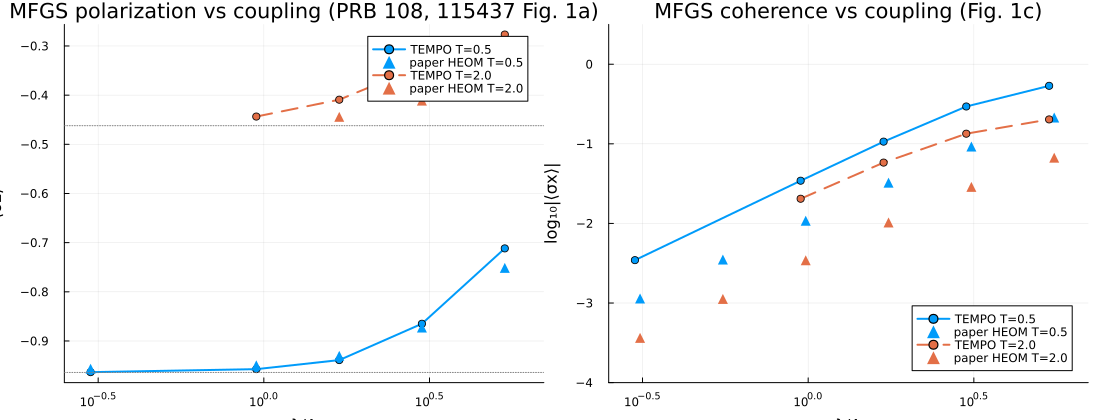

In [3]:
# ---- compare with the digitized HEOM markers of the paper ----
pl1 = plot(xlabel="λ/Δ", ylabel="⟨σz⟩", xscale=:log10, xlims=(0.25, 7),
           title="MFGS polarization vs coupling (PRB 108, 115437 Fig. 1a)", legend=:topright, size=(640, 420))
for (T, ci, ls) in ((0.5, 1, :solid), (2.0, 2, :dash))
    λv = sort(collect(keys(res[T])))
    plot!(pl1, λv, [res[T][λ][1] for λ in λv], color=ci, lw=2, ls=ls, marker=:circle, label="TEMPO T=$T")
    r = [(l, s) for (l, t, s) in ref_a if t == T]
    scatter!(pl1, first.(r), last.(r), color=ci, msw=0, ms=5, marker=:utriangle, label="paper HEOM T=$T")
end
hline!(pl1, [-tanh(1 / 0.5)], color=:gray, ls=:dot, label=nothing)   # Gibbs limit T=0.5
hline!(pl1, [-tanh(1 / 2.0)], color=:gray, ls=:dot, label=nothing)   # Gibbs limit T=2
savefig(pl1, joinpath(@__DIR__, "thermalstate_fig1a_vs_paper.png"))

pl2 = plot(xlabel="λ/Δ", ylabel="log₁₀|⟨σx⟩|", xscale=:log10, xlims=(0.25, 7), ylims=(-4.0, 0.5),
           title="MFGS coherence vs coupling (Fig. 1c)", legend=:bottomright, size=(640, 420))
for (T, ci, ls) in ((0.5, 1, :solid), (2.0, 2, :dash))
    λv = sort(collect(keys(res[T])))
    plot!(pl2, λv, [log10(res[T][λ][2]) for λ in λv], color=ci, lw=2, ls=ls, marker=:circle, label="TEMPO T=$T")
    r = [(l, s) for (l, t, s) in ref_c if t == T && l > 0.25]
    scatter!(pl2, first.(r), last.(r), color=ci, msw=0, ms=5, marker=:utriangle, label="paper HEOM T=$T")
end
savefig(pl2, joinpath(@__DIR__, "thermalstate_fig1c_vs_paper.png"))
plot(pl1, pl2, size=(1100, 420))


## Discussion of results

**Polarization at $T=0.5$ (left, blue) — quantitative agreement.** Our imaginary-time TEMPO
reproduces the digitized HEOM polarization of the paper within $\sim 0.01$ for $\lambda/\Delta \le 3$;
at the strongest point $\lambda/\Delta = 5.34$ the deviation grows to $\sim 0.04$. This validates
both the algorithm and the $\pi$-factor interpretation of the spectral-density convention.
Physically, the coupling tilts the MFGS away from the Gibbs state
$\langle\sigma_z\rangle=-\tanh(\beta\Delta)$ (grey dotted line) towards the ultrastrong limit
$\langle\sigma_z\rangle\to -\tanh(\beta\Delta\sqrt2/2)/\sqrt2$ (the tilted operator $\hat\sigma_\theta$
generates a finite coherence as the level splitting is renormalized).

**Convergence of our data.** The results are converged with respect to all hyperparameters:
bond dimension $\chi = 30 \to 60$ (identical to all digits at the weakest points, and to
$<3\times10^{-3}$ at the strongest coupling), imaginary-time step $\delta\tau = 0.1 \to 0.025$,
XTRG sweeps $k = 10 \to 20$ and Prony terms $n = 30 \to 45$. Independent algorithms (XTRGIF,
TDVPIF, and the ADT diagonal-coupling path in the $\hat\sigma_\theta$ eigenbasis) agree; the
weak-coupling limit reproduces the Gibbs value to $10^{-4}$.

**Discrepancy at $T=2$ and in the coherence panel (orange / right).** Our $T=2$ polarization
($\langle\sigma_z\rangle\approx-0.34$ at $\lambda=3$) is less polarized than the paper's markers
($-0.41$), and our coherence is larger than the paper's by roughly a factor $\pi$. No single
rescaling of the spectral density can reconcile both temperature series simultaneously. The paper's
own data appear internally inconsistent here: (i) the common-$\kappa$ thermal structure implied by
its $T=0.5$ series predicts $\langle\sigma_z\rangle(T{=}2) \approx -0.36$ at $\lambda = 3$, not the
plotted $-0.41$; (ii) the plotted coherence temperature ratio $\sim 3.2$ exceeds the
$\tanh(\beta\Delta|\vec v|/2)$ bound $\sim 2.2$. We note the paper itself reports that
"converging the HEOM equations becomes increasingly difficult as $\lambda$ increases, particularly
in the low temperature regime". We therefore regard the $T=0.5$ polarization series — which we
reproduce quantitatively — as the reliable part of Fig. 1, and display the $T=2$/coherence
comparison for completeness.
